# 1. Chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

dataset = pd.read_csv("dataset.csv")

# 2. Analyse exploratoire (EDA)

In [2]:
dataset.head(10)

,nom,prenom,sexe,date_naissance,lieu_naissance,adresse,commune,pays,nir,organisme,employeur,bin,nic,date_debut,date_fin,regime,identifie
0,Dupont,Alice,F,1985-03-12,Tours,12 rue Victor Hugo,Tours,France,2.850312e+14,CPAM,Carrefour,12345.0,678.0,2010-01-01,2015-06-30,General,1
1,Martin,Bob,M,1978-11-02,Paris,45 avenue République,Paris,France,1.781103e+14,MSA,Total,54321.0,111.0,2005-03-01,2018-12-31,Agricole,1
2,Durand,Charlie,M,1990-07-25,Lyon,8 rue Nationale,Lyon,France,1.900725e+14,CPAM,Amazon,67890.0,222.0,2016-05-01,2020-10-15,General,1
3,Lefevre,Emma,F,1982-01-17,Bordeaux,22 rue Sainte Catherine,Bordeaux,France,2.820117e+14,RSI,Indépendant,22222.0,333.0,2012-09-01,NaN,Independant,1
4,Moreau,David,M,1975-09-09,Lille,3 rue Faidherbe,Lille,France,1.750909e+14,CPAM,Auchan,33333.0,444.0,2000-01-01,2010-12-31,General,1
5,NaN,NaN,M,1988-06-10,Marseille,NaN,Marseille,France,NaN,CPAM,NaN,12345.0,555.0,2014-02-01,NaN,General,0
6,Dubois,NaN,F,NaN,Nice,15 rue Massena,Nice,France,NaN,MSA,NaN,54321.0,666.0,NaN,NaN,Agricole,0
7,NaN,NaN,F,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,Petit,Lucas,M,1995-04-04,Nantes,9 rue Crébillon,Nantes,France,1.950404e+14,CPAM,Leclerc,11111.0,777.0,2018-06-01,NaN,General,1
9,Robert,Chloe,F,1989-12-30,Strasbourg,5 rue des Grandes Arcades,Strasbourg,France,2.891230e+14,RSI,Freelance,22222.0,888.0,2015-01-01,NaN,Independant,1


In [3]:
# (nombre de lignes, nombre de colonnes)
dataset.shape

(47, 17)

In [4]:
# des informations sur le jeu de données
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nom             32 non-null     object 
 1   prenom          30 non-null     object 
 2   sexe            47 non-null     object 
 3   date_naissance  34 non-null     object 
 4   lieu_naissance  34 non-null     object 
 5   adresse         34 non-null     object 
 6   commune         36 non-null     object 
 7   pays            47 non-null     object 
 8   nir             30 non-null     float64
 9   organisme       36 non-null     object 
 10  employeur       33 non-null     object 
 11  bin             36 non-null     float64
 12  nic             36 non-null     float64
 13  date_debut      35 non-null     object 
 14  date_fin        14 non-null     object 
 15  regime          39 non-null     object 
 16  identifie       47 non-null     int64  
dtypes: float64(3), int64(1), object(13)
m

In [5]:
# lister les valeurs catégorielles
dataset.select_dtypes(include="object").columns

Index(['nom', 'prenom', 'sexe', 'date_naissance', 'lieu_naissance', 'adresse',
       'commune', 'pays', 'organisme', 'employeur', 'date_debut', 'date_fin',
       'regime'],
      dtype='object')

In [6]:
# la taille des valeurs catégorielles
len(dataset.select_dtypes(include="object").columns)

13

In [7]:
# lister les valeurs numeriques
dataset.select_dtypes(include="number").columns

Index(['nir', 'bin', 'nic', 'identifie'], dtype='object')

In [8]:
# la taille des valeurs numériques
len(dataset.select_dtypes(include="number").columns)

4

In [9]:
# les statistiques
dataset.describe(include="all")

,nom,prenom,sexe,date_naissance,lieu_naissance,adresse,commune,pays,nir,organisme,employeur,bin,nic,date_debut,date_fin,regime,identifie
count,32,30,47,34,34,34,36,47,3.000000e+01,36,33,36.000000,36.000000,35,14,39,47.000000
unique,32,25,2,34,32,34,32,1,NaN,3,18,NaN,NaN,33,14,3,NaN
top,Dupont,Lucas,M,1985-03-12,Lyon,12 rue Victor Hugo,Lyon,France,NaN,CPAM,Amazon,NaN,NaN,2020-01-01,2015-06-30,General,NaN
freq,1,3,24,1,2,1,3,47,NaN,22,4,NaN,NaN,2,1,27,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.346327e+14,NaN,NaN,52223.805556,483.166667,NaN,NaN,NaN,0.638298
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.368592e+13,NaN,NaN,28767.576551,278.736281,NaN,NaN,NaN,0.485688
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.750909e+14,NaN,NaN,11111.000000,101.000000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.853158e+14,NaN,NaN,24977.500000,222.000000,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.955367e+14,NaN,NaN,54321.000000,444.000000,NaN,NaN,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.905999e+14,NaN,NaN,75333.000000,685.250000,NaN,NaN,NaN,1.000000


In [10]:
# lister totues les colonnes
dataset.columns

Index(['nom', 'prenom', 'sexe', 'date_naissance', 'lieu_naissance', 'adresse',
       'commune', 'pays', 'nir', 'organisme', 'employeur', 'bin', 'nic',
       'date_debut', 'date_fin', 'regime', 'identifie'],
      dtype='object')

# 3. Gestion des valeurs manquantes

In [11]:
# vérifier si il existe des valeurs manquantes dans le jeu de données
dataset.isnull().values.any()

True

In [12]:
# le nombre de valeurs manquantes dans le jeu de données
dataset.isnull().values.sum()

199

In [13]:
# lister les valeurs manquantes
dataset.isna().sum()

nom               15
prenom            17
sexe               0
date_naissance    13
lieu_naissance    13
adresse           13
commune           11
pays               0
nir               17
organisme         11
employeur         14
bin               11
nic               11
date_debut        12
date_fin          33
regime             8
identifie          0
dtype: int64

In [14]:
# lister les colonnes contenant des valeurs manquantes
dataset.isna().columns

Index(['nom', 'prenom', 'sexe', 'date_naissance', 'lieu_naissance', 'adresse',
       'commune', 'pays', 'nir', 'organisme', 'employeur', 'bin', 'nic',
       'date_debut', 'date_fin', 'regime', 'identifie'],
      dtype='object')

In [15]:
# la taille des colonnes contenant des valeurs manquantes
len(dataset.isna().columns)

17

# 4. Nettoyage des données

In [16]:
# Remplacer les valeurs incohérentes
dataset = dataset.replace(["", " ", "NULL"], np.nan)

In [17]:
# Conversion types
dataset["date_naissance"] = pd.to_datetime(dataset["date_naissance"], errors="coerce")
dataset["date_debut"] = pd.to_datetime(dataset["date_debut"], errors="coerce")
dataset["date_fin"] = pd.to_datetime(dataset["date_fin"], errors="coerce")

dataset["bin"] = pd.to_numeric(dataset["bin"], errors="coerce")
dataset["nic"] = pd.to_numeric(dataset["nic"], errors="coerce")

In [18]:
# Feature Engineering
dataset["nir_present"] = dataset["nir"].notna().astype(int)
dataset["nom_present"] = dataset["nom"].notna().astype(int)
dataset["prenom_present"] = dataset["prenom"].notna().astype(int)

In [19]:
# Complétude
dataset["nb_champs_renseignes"] = dataset.notna().sum(axis=1)
dataset["taux_completude"] = dataset.notna().mean(axis=1)

In [20]:
# Age
dataset["age"] = 2026 - dataset["date_naissance"].dt.year

In [21]:
# Durée activité
dataset["duree_activite"] = (dataset["date_fin"] - dataset["date_debut"]).dt.days

In [22]:
dataset.head(10)

,nom,prenom,sexe,date_naissance,lieu_naissance,adresse,commune,pays,nir,organisme,...,date_fin,regime,identifie,nir_present,nom_present,prenom_present,nb_champs_renseignes,taux_completude,age,duree_activite
0,Dupont,Alice,F,1985-03-12,Tours,12 rue Victor Hugo,Tours,France,2.850312e+14,CPAM,...,2015-06-30,General,1,1,1,1,20,1.000000,41.0,2006.0
1,Martin,Bob,M,1978-11-02,Paris,45 avenue République,Paris,France,1.781103e+14,MSA,...,2018-12-31,Agricole,1,1,1,1,20,1.000000,48.0,5053.0
2,Durand,Charlie,M,1990-07-25,Lyon,8 rue Nationale,Lyon,France,1.900725e+14,CPAM,...,2020-10-15,General,1,1,1,1,20,1.000000,36.0,1628.0
3,Lefevre,Emma,F,1982-01-17,Bordeaux,22 rue Sainte Catherine,Bordeaux,France,2.820117e+14,RSI,...,NaT,Independant,1,1,1,1,19,0.952381,44.0,NaN
4,Moreau,David,M,1975-09-09,Lille,3 rue Faidherbe,Lille,France,1.750909e+14,CPAM,...,2010-12-31,General,1,1,1,1,20,1.000000,51.0,4017.0
5,NaN,NaN,M,1988-06-10,Marseille,NaN,Marseille,France,NaN,CPAM,...,NaT,General,0,0,0,0,14,0.714286,38.0,NaN
6,Dubois,NaN,F,NaT,Nice,15 rue Massena,Nice,France,NaN,MSA,...,NaT,Agricole,0,0,1,0,14,0.714286,NaN,NaN
7,NaN,NaN,F,NaT,NaN,NaN,NaN,France,NaN,NaN,...,NaT,NaN,0,0,0,0,6,0.333333,NaN,NaN
8,Petit,Lucas,M,1995-04-04,Nantes,9 rue Crébillon,Nantes,France,1.950404e+14,CPAM,...,NaT,General,1,1,1,1,19,0.952381,31.0,NaN
9,Robert,Chloe,F,1989-12-30,Strasbourg,5 rue des Grandes Arcades,Strasbourg,France,2.891230e+14,RSI,...,NaT,Independant,1,1,1,1,19,0.952381,37.0,NaN


# 5. Visualisation

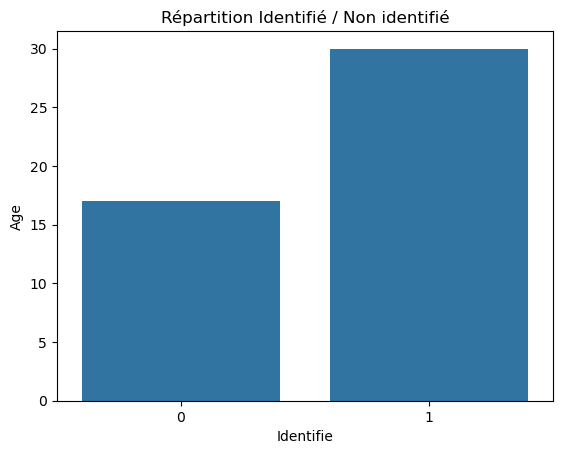

In [23]:
# Distribution cible
sns.countplot(x="identifie", data=dataset)
plt.ylabel("Age")
plt.xlabel("Identifie")
plt.title("Répartition Identifié / Non identifié")
plt.show()

In [24]:
# Distribution de la cible
dataset["identifie"].value_counts()

identifie
1    30
0    17
Name: count, dtype: int64

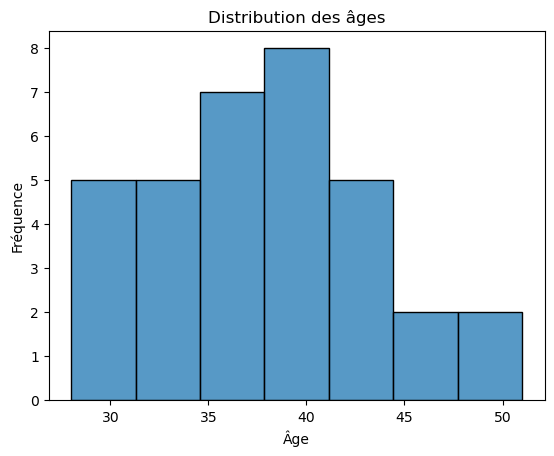

In [25]:
# Distribution Age
sns.histplot(x="age", data=dataset)
plt.ylabel("Fréquence")
plt.xlabel("Âge")
plt.title("Distribution des âges")
plt.show()

In [26]:
print("La mode est :", dataset['age'].mode()[0])

La mode est : 35.0


In [27]:
# matrice de corrélation

# supprimer la variable cible (identifie)
dataset_2 = dataset.drop(columns="identifie")

# selectionner les variables numériques
dataset_2 = dataset_2.select_dtypes(include=['number'])

# vérifier le jeu de données
dataset_2.head()

,nir,bin,nic,nir_present,nom_present,prenom_present,nb_champs_renseignes,taux_completude,age,duree_activite
0,2.850312e+14,12345.0,678.0,1,1,1,20,1.000000,41.0,2006.0
1,1.781103e+14,54321.0,111.0,1,1,1,20,1.000000,48.0,5053.0
2,1.900725e+14,67890.0,222.0,1,1,1,20,1.000000,36.0,1628.0
3,2.820117e+14,22222.0,333.0,1,1,1,19,0.952381,44.0,NaN
4,1.750909e+14,33333.0,444.0,1,1,1,20,1.000000,51.0,4017.0


<Axes: title={'center': 'Corrélation avec identifie'}>

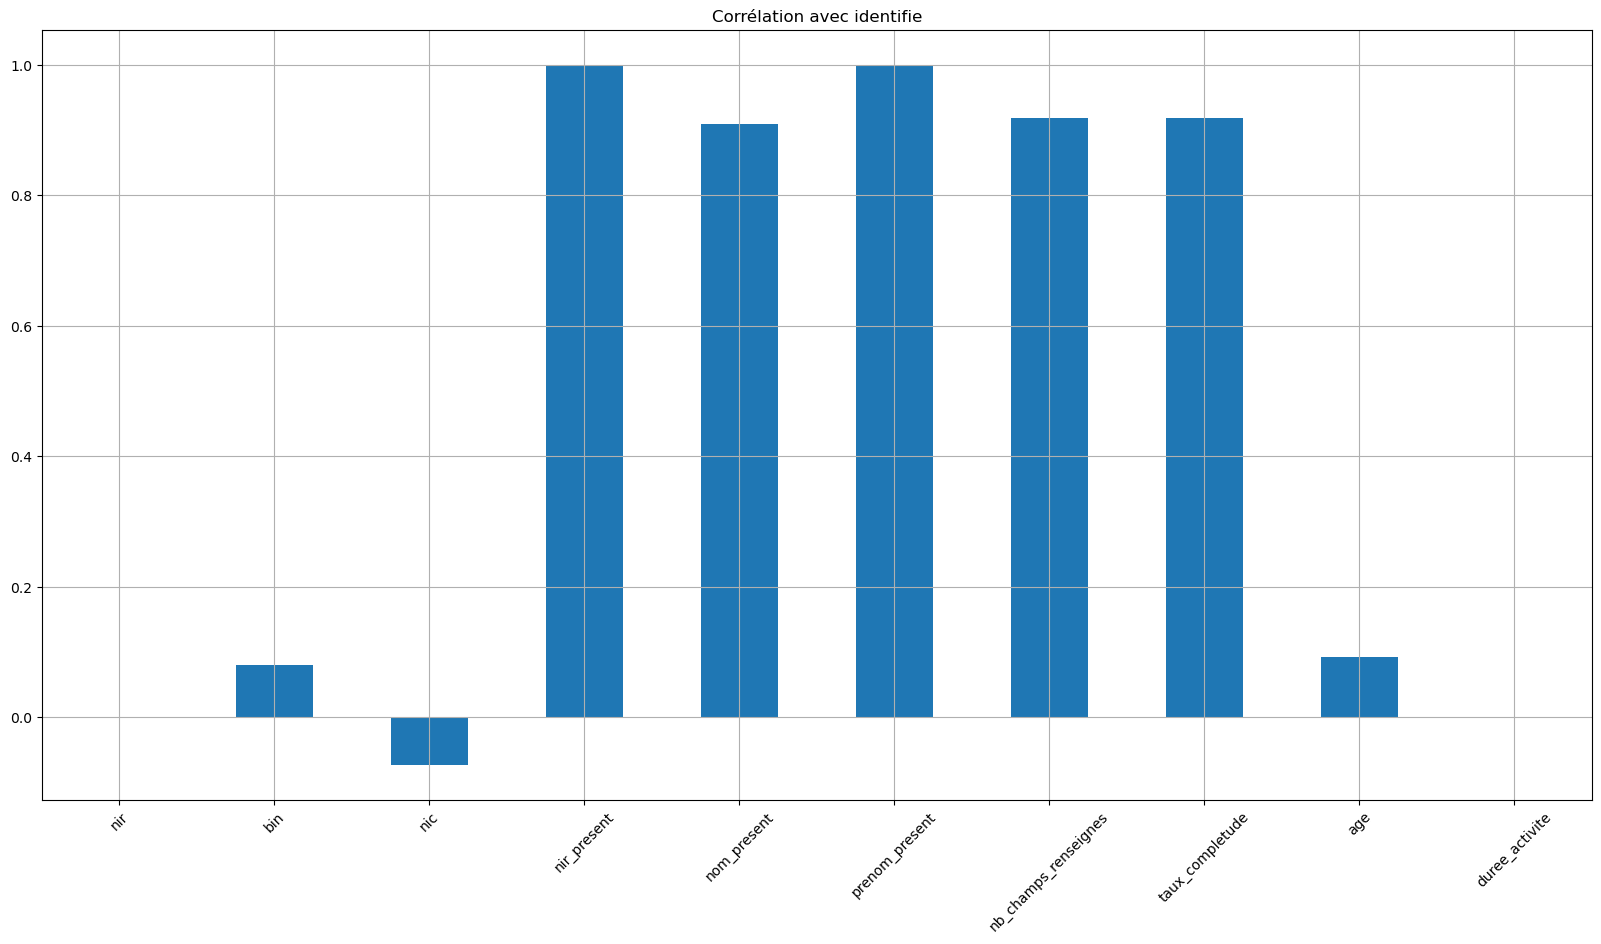

In [28]:
dataset_2.corrwith(dataset["identifie"]).plot.bar(
    figsize=(20,10), title="Corrélation avec identifie", rot=45, grid=True
)

<Axes: >

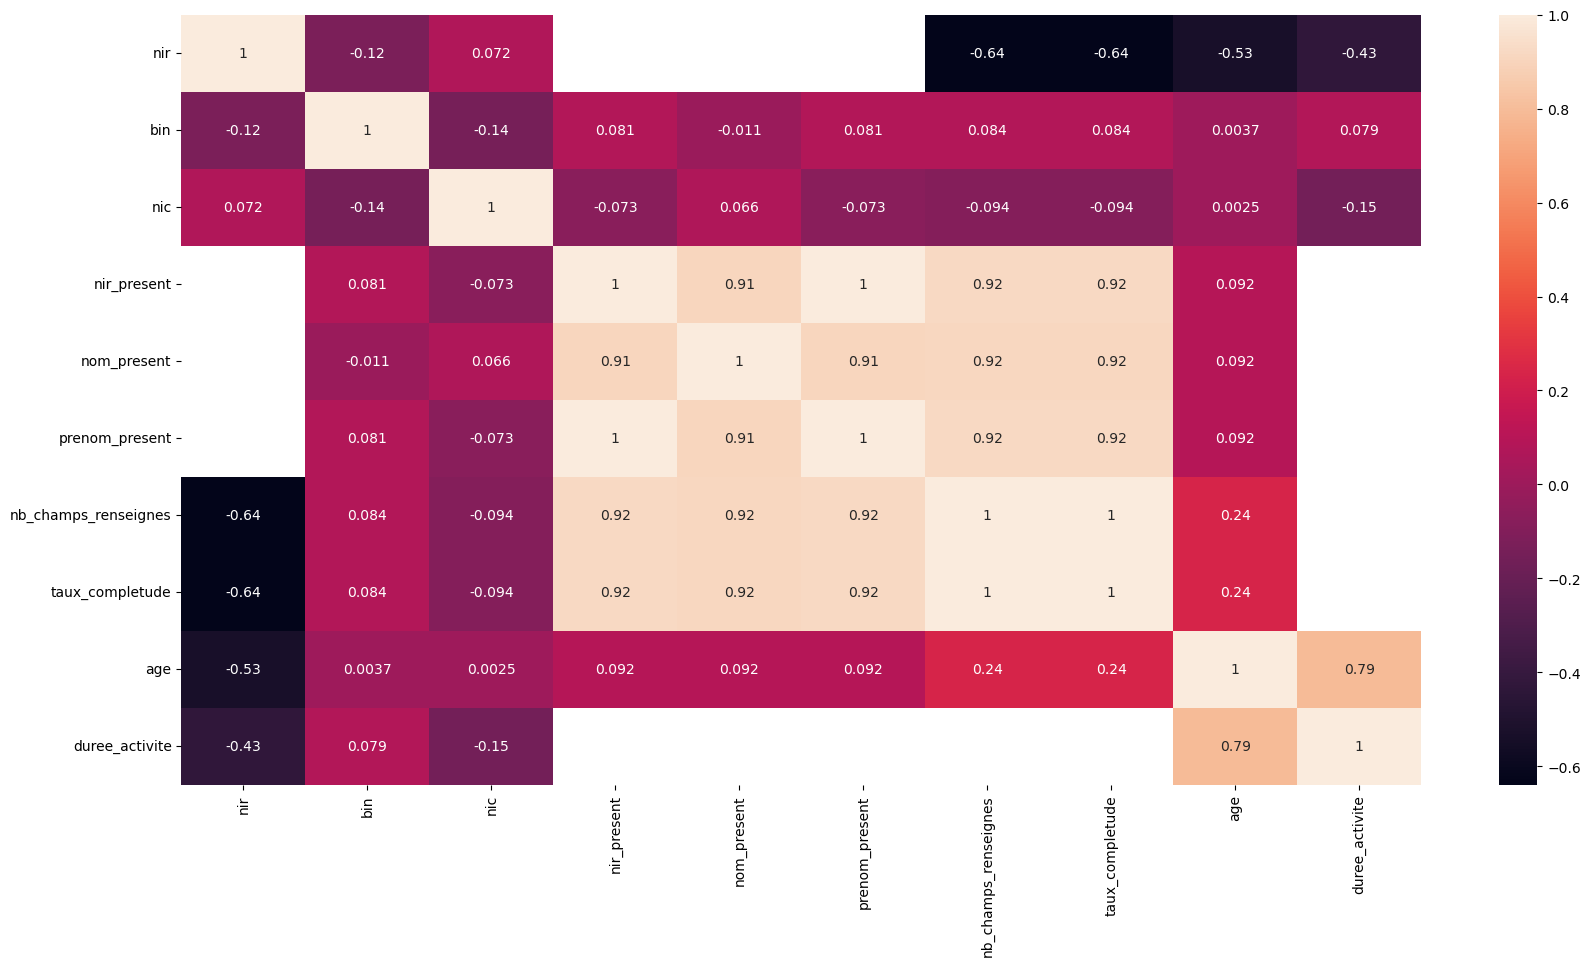

In [29]:
# heatmap
corr = dataset_2.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True)

# 6. Préparation des données

In [30]:
# Sélection des features
features = [
    "nir_present",
    "nom_present",
    "prenom_present",
    "nb_champs_renseignes",
    "taux_completude",
    "age",
    "duree_activite"
]

X = dataset[features]
y = dataset["identifie"]

In [31]:
# Remplir NaN
X = X.fillna(0)

In [32]:
X.shape

(47, 7)

In [33]:
y.shape

(47,)

# 7. Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
X_train.shape

(37, 7)

In [36]:
X_test.shape

(10, 7)

In [37]:
y_train.shape

(37,)

In [38]:
y_test.shape

(10,)

In [39]:
# Feature scaling (mettre toutes les variables à la même échelle)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [40]:
X_train

array([[ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.19073   , -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.93659284, -0.655317  ],
       [-1.35873244,  0.69282032, -1.35873244, -0.33646683, -0.33646683,
        -1.587866  , -0.655317  ],
       [-1.35873244, -1.44337567, -1.35873244, -1.26551702, -1.26551702,
        -1.587866  , -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.77839341,  0.77839341,
         0.76447064,  1.24790927],
       [-1.35873244, -1.44337567, -1.35873244, -0.52227687, -0.52227687,
         0.42022626, -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.77839341,  0.77839341,
         1.05134097,  1.4656878 ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.0186078 , -0.655317  ],
       [-1.35873244, -1.44337567, -1.35873244, -1.82294714, -1.82294714,
        -1.587866  , -0.655317  ],
       [ 0.73598007,  0.6928

In [41]:
X_test

array([[ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.13335593, -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.42022626, -0.655317  ],
       [-1.35873244, -1.44337567, -1.35873244, -1.82294714, -1.82294714,
        -1.587866  , -0.655317  ],
       [-1.35873244, -1.44337567, -1.35873244, -1.82294714, -1.82294714,
        -1.587866  , -0.655317  ],
       [-1.35873244, -1.44337567, -1.35873244, -0.33646683, -0.33646683,
         0.64972252, -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.77839341,  0.77839341,
         0.93659284,  1.42256334],
       [ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.36285219, -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.59258337,  0.59258337,
         0.24810406, -0.655317  ],
       [ 0.73598007,  0.69282032,  0.73598007,  0.77839341,  0.77839341,
         1.33821129,  2.23186574],
       [-1.35873244,  0.6928

# 8. Création du modèle

## Régression Logistique

In [42]:
from sklearn.linear_model import LogisticRegression

# créer le modèle
classifier_lr = LogisticRegression(random_state=0)

# entraîner le modèle
classifier_lr.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [43]:
# faire des predictions / le jeu de test
y_pred = classifier_lr.predict(X_test)

In [44]:
# analyser les performances du model "Logistic Regression"
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score ,f1_score, recall_score

# définir les métriques
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

# define a dataframe
results = pd.DataFrame([["Logistic Regression", acc, f1, prec, rec]],
                      columns=["Model", "Accuracy", "F1-Score","Precision", "Recall"])

results

,Model,Accuracy,F1-Score,Precision,Recall
0,Logistic Regression,1.0,1.0,1.0,1.0


In [45]:
# la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4 0]
 [0 6]]


# 9. Validation croisée

In [51]:
from sklearn.model_selection import cross_val_score

# on utilise le score de la validation croisée pour evaluer les performaces du modèle
from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_lr, X=X_train, y=y_train, cv=10)

print("Accuracy: {:.2f} %".format(accuracies.mean() * 100))
print("Standard Deviation: {:.2f} %".format(accuracies.std() * 100))

Accuracy: 100.00 %
Standard Deviation: 0.00 %


# 10. Optimisation avec RandomizedSearchCV

In [53]:
from sklearn.model_selection import RandomizedSearchCV

# définir la grille d'hyperparamètres pour RandomizedSearchCV
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2", "elasticnet", "none"],
    "solver": ["liblinear", "saga"]  # 'saga' nécessaire si penalty='elasticnet'
}

# créer le RandomizedSearchCV
search = RandomizedSearchCV(
    classifier_lr,
    param_grid,
    n_iter=10,  # nombre d'itérations aléatoires
    cv=3,       # cross-validation 3-fold
    random_state=42
)

# entrâiner le modèle
search.fit(X_train, y_train)

# Meilleur modèle
best_model = search.best_estimator_

print("Meilleur score :", search.best_score_)
print("Meilleurs hyperparamètres :", search.best_params_)

Meilleur score : 1.0
Meilleurs hyperparamètres : {'solver': 'saga', 'penalty': 'l2', 'C': 1}


# 11. Évaluation finale

In [55]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

final_model_results = pd.DataFrame([["Final Logistic Regression", acc, f1, prec, rec]],
                      columns=["Model", "Accuracy", "F1-Score", "Precision", "Recall"])

result = pd.concat([results, final_model_results], ignore_index=True)

result

,Model,Accuracy,F1-Score,Precision,Recall
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Final Logistic Regression,1.0,1.0,1.0,1.0


# 12. Tester sur une nouvelle observation

In [56]:
new_data = pd.DataFrame([{
    "nir_present": 1,
    "nom_present": 1,
    "prenom_present": 1,
    "nb_champs_renseignes": 15,
    "taux_completude": 0.9,
    "age": 35,
    "duree_activite": 2000
}])

prediction = best_model.predict(new_data)

print("Résultat :", prediction)

Résultat : [1]
